In [88]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import matplotlib.pyplot as plt
from category_encoders import TargetEncoder
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

In [121]:
train = pd.read_csv("train.csv")
print(len(train))
train.head()

1460


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Train Test Split

In [131]:
X = train.drop('SalePrice', axis=1)
y = train['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

### Take out the outliers

<Axes: xlabel='SalePrice'>

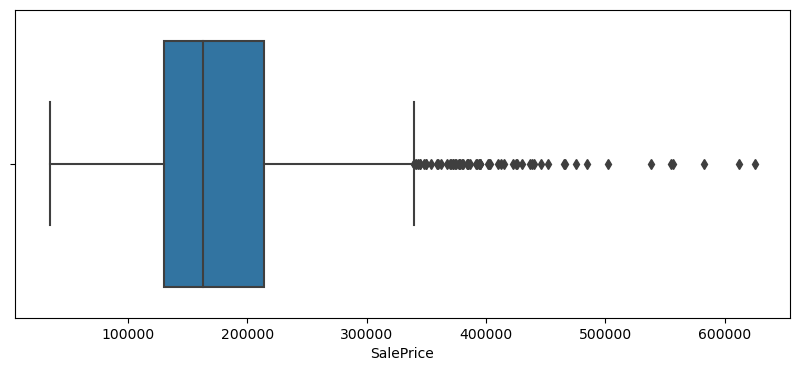

In [60]:
import seaborn as sns

plt.figure(figsize=(10, 4))
sns.boxplot(x=y)

In [63]:
train = train[train['SalePrice'] < 700000]

### Address Missing Data

In [132]:
#How many missing values are in each column
train.isnull().sum().sort_values(ascending=False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Id                 0
dtype: int64

#### Missing Values and their descriptions

PoolQC: Pool quality (Excellent, Good)

MiscFeature: Miscellaneous feature not covered in other categories

Alley: Type of alley access to property

Fence: Fence quality

MasVnrType: Masonry veneer type

FireplaceQu: Fireplace quality

LotFrontage: Linear feet of street connected to property

GarageYrBlt: Year garage was built

GarageCond: Garage condition

GarageType   
GarageFinish   
GarageQual    

BsmtFinType2: Rating of basement finished area (if multiple types)

BsmtExposure     
BsmtQual         
BsmtCond         
BsmtFinType1 

MasVnrArea: Masonry veneer area in square feet

Electrical: Electrical system

### Tranform PoolQC to hasPool

#### Pool quality
Transform PoolQC to hasPool column because 99.5% of rows have value None for PoolQC.

PoolQC: Ex(Excellent), Gd(Good), TA(Average), Fa(Fair), NA -> hasPool: 0 or 1

In [65]:
def handle_pool_logic(df):
    df = df.copy()
    df['hasPool'] = df['PoolQC'].notnull().astype(int)
    df = df.drop(columns=['PoolQC'])
    return df

pool_transformer = FunctionTransformer(handle_pool_logic)

pipeline = Pipeline([
    ('pool_handler', pool_transformer),
])

### Impute Null Values in Categorical Columns with 'NA'

If MiscFeature, Alley, Fence, FireplaceQu, GarageCond, GarageType, GarageFinish, GarageQual, BsmtFinType2, BsmtExposure, BsmtQual, BsmtCond, BsmtFinType1, Electrical, MasVnrType is None, replace with "NA"

Possible redudancy between "Fireplaces" and "FireplaceQu"

Possible redudancy between NA's of GarageCond, GarageType, GarageFinish, GarageQual

In [66]:
na_imputer = SimpleImputer(strategy='constant', fill_value='NA')

na_cat_columns = ["MiscFeature", "Alley", "Fence", "MasVnrType", "FireplaceQu", "GarageCond", "GarageType",
                  "GarageFinish", "GarageQual", "BsmtFinType2", "BsmtExposure", "BsmtQual", "BsmtCond", 
                  "BsmtFinType1", "Electrical"]

preprocessor = ColumnTransformer(transformers=[
    ('impute_na_categorical', na_imputer, na_cat_columns)
], remainder='passthrough')

pipeline = Pipeline([
    ('pool_handler', pool_transformer),
    ('fill_na', preprocessor)
])

#### How to test parts of pipeline individually

##### For one piece of the pipeline
transformed_sample = pipeline.named_steps['pool_handler'].transform(train.head())


##### For whole pipeline
pipeline.set_output(transform="pandas")

transformed = pipeline.fit_transform(train)


### Impute null values in LotFrontage, GarageYrBlt with their median values


In [67]:
median_imputer = SimpleImputer(strategy = 'median')
median_columns = ["LotFrontage", "GarageYrBlt"]

#Consolidate previous and current ColumnTransformer into one.
preprocessor = ColumnTransformer(transformers=[
    ('impute_na_categorical', na_imputer, na_cat_columns),
    ('impute_median', median_imputer, median_columns),
], remainder='passthrough')

pipeline = Pipeline([
    ('pool_handler', pool_transformer),
    ('preprocessor', preprocessor)
])

In [68]:
pipeline.set_output(transform="pandas")
transformed = pipeline.fit_transform(train)

In [69]:
train["LotFrontage"] = train["LotFrontage"].fillna(train["LotFrontage"].median())
train["GarageYrBlt"] = train["GarageYrBlt"].fillna(train["GarageYrBlt"].median())

### Impute null values in MasVnrArea with 0

In [71]:
impute_0 = SimpleImputer(strategy = 'constant', fill_value = 0)

#Consolidate previous and current ColumnTransformer into one.
preprocessor = ColumnTransformer(transformers=[
    ('impute_na_categorical', na_imputer, na_cat_columns),
    ('impute_median', median_imputer, median_columns),
    ('impute_0', impute_0, ["MasVnrArea"])
], remainder='passthrough')

pipeline = Pipeline([
    ('pool_handler', pool_transformer),
    ('preprocessor', preprocessor)
])

### One hot encode the categorical columns and add linear regressor
### ColumnTransformer vs Pipeline in sklearn

Before I was imputing categorical variables and one hot encoding categorical variables in the same ColumnTransformer. This doesn't work because some categorical columns end up in the final dataframe without one hot encoding. This is because every item in ColumnTransformer sends it output directly to the final dataframe. Instead if we use Pipeline, the categorical data would be imputed first and then will be passed onto the one hot encoder step. 



ColumnTransformer on the column Street
 - impute missing values in Street column with 'NA' and return Street_imputed as a column
 - one hot encode Street column as Street_gravel and Street_paved and return those as column

The problem is that Street_imputed still contains text which is not acceptable for the model

Pipeline on column Street
- impute missing values in Street column with 'NA' and pass result to the next step in the pipeline
- one hot encode Street column as Street_gravel and Street_paved and return those as columns because this is the last step of the pipeline

Put categorical columns that need both imputatation and OHE into cat_impute_ohe pipeline, while categorical columns that only need OHE do not need a seperate pipeline.

#### Linear Regressor

In [73]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

categorical_cols = ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
    'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 
        'KitchenQual',
        'Functional', 'FireplaceQu', 'GarageType',
        'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'Fence',
       'MiscFeature', 'SaleType',
       'SaleCondition']

#categorical columns that only need OHE
cat_ohe_columns = list(set(categorical_cols) - set(na_cat_columns))

#For categorical columns where you need to impute missing values and do OHE
cat_impute_ohe_pipeline = Pipeline([
    ('impute_na_categorical', na_imputer),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

#Consolidate previous and current ColumnTransformer into one, add OHE.
preprocessor = ColumnTransformer(transformers=[
    ('cat_impute_ohe', cat_impute_ohe_pipeline, na_cat_columns), #for cat columns that need imputation and OHE
    ('cat_ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_ohe_columns), #cat columns that ony need OHE
    ('impute_median', median_imputer, median_columns),
    ('impute_0', impute_0, ["MasVnrArea"])
], remainder='passthrough')

#Add linear regressor
pipeline = Pipeline([
    ('pool_handler', pool_transformer),
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])


### Add TranformerTargetRegressor to log transform the y variable

Apparently, its useful to log tranform the y variable if it is skewed. The graph below shows that the y variable, SalePrice is right skewed. Otherwise penalty for wrongly predicting the sale price of expensive houses is proportionally larger than the penalty for wrongly predicting sale prices for average cost houses. 

TransformerTargetRegressor wraps a sklearn pipeline and takes care of log transforming the y variable before data is passed into the model and does expm1 (exponential) on the model's outputs to restore the predictions back to their original units.

<Axes: >

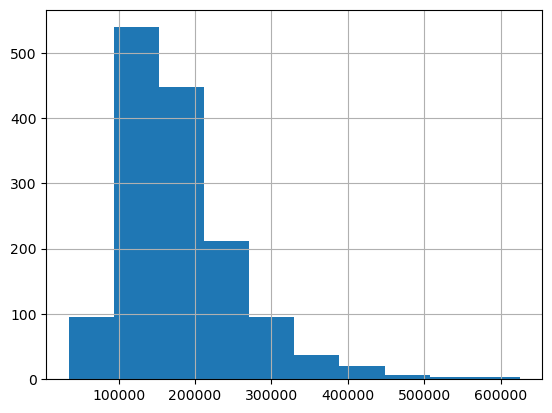

In [74]:
train['SalePrice'].hist()

#### Wrap the sklearn Pipeline in a TransformedTargetRegressor

In [75]:
model = TransformedTargetRegressor(
    regressor=pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

#### Cross Validation Scores for RMSE and MAPE(Mean Absolute Percentage Error)

In [79]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error')
mapes = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_percentage_error')
np.mean(scores) * -1, np.mean(mapes) * -1


(49366.31067456507, 0.10239281661390343)

#### Ridge Regressor

In [22]:
pipeline = Pipeline([
    ('pool_handler', pool_transformer),
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

#for log transforming the y variable
model = TransformedTargetRegressor(
    regressor=pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

#hyperparameter tune
param_grid = {
    'regressor__model__alpha': [0.1, 1.0, 10.0, 100.0]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid, 
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

grid_search.fit(X, y)

print("Ridge Regression Grid Search Results")
print(f"Best RMSE: {-grid_search.best_score_:.2f}")
print(f"Best Parameters: {grid_search.best_params_}")

Ridge Regression Grid Search Results
Best RMSE: 51165.45
Best Parameters: {'regressor__model__alpha': 1.0}


#### Lasso Regressor

In [23]:
pipeline = Pipeline([
    ('pool_handler', pool_transformer),
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=1.0))
])

#for log transforming the y variable
model = TransformedTargetRegressor(
    regressor=pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

#hyperparameter tune
param_grid = {
    'regressor__model__alpha': [0.1, 1.0, 10.0, 100.0, 1000]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid, 
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

grid_search.fit(X, y)

print("Lasso Regression Grid Search Results")
print(f"Best RMSE: {-grid_search.best_score_:.2f}")
print(f"Best Parameters: {grid_search.best_params_}")

Lasso Regression Grid Search Results
Best RMSE: 77109.66
Best Parameters: {'regressor__model__alpha': 100.0}


#### XGBoost

In [24]:
xgb_model = XGBRegressor(
    n_estimators=1000,   # Number of trees
    learning_rate=0.05,  # How much to "listen" to each tree
    max_depth=5,         # How complex each tree can be
    random_state=42
)

pipeline = Pipeline([
    ('pool_handler', pool_transformer),
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])

model = TransformedTargetRegressor(
    regressor=pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

#hyperparameter tune
param_grid = {
    'regressor__model__n_estimators': [250, 500],      
    'regressor__model__learning_rate': [0.1, 0.2, 0.4],   
    'regressor__model__max_depth': [3],
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid, 
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

grid_search.fit(X, y)

print("XGBoost Regression Grid Search Results")
print(f"Best RMSE: {-grid_search.best_score_:.2f}")
print(f"Best Parameters: {grid_search.best_params_}")

XGBoost Regression Grid Search Results
Best RMSE: 28319.81
Best Parameters: {'regressor__model__learning_rate': 0.2, 'regressor__model__max_depth': 3, 'regressor__model__n_estimators': 500}


### Feature Engineering

#### How many years old is the house? - Feature Engineering

Assume this dataset goes up to the year 2010.

In [25]:
X['YearRemodAdd'].sort_values(ascending=False).head()

987    2010
898    2010
855    2010
378    2010
157    2010
Name: YearRemodAdd, dtype: int64

In [26]:
2010 - X['YearBuilt'].head()

0     7
1    34
2     9
3    95
4    10
Name: YearBuilt, dtype: int64

In [27]:
#possibly add YrSold to this too
def house_age(df):
    df = df.copy()
    df['YearBuilt'] = 2010 - df['YearBuilt']
    #df['YearRemodAdd'] = 2010 - df['YearRemodAdd']
    return df

house_age_transformer = FunctionTransformer(house_age)

#Add linear regressor
pipeline = Pipeline([
    ('house_age', house_age_transformer),
    ('pool_handler', pool_transformer),
    ('preprocessor', preprocessor),
    #('model', LinearRegression())
    ('model', xgb_model)
])

model = TransformedTargetRegressor(
    regressor=pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

#hyperparameter tune
param_grid = {
    'regressor__model__n_estimators': [250, 500, 1000],      
    'regressor__model__learning_rate': [0.1, 0.2, 0.4],   
    'regressor__model__max_depth': [1, 3, 5],
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid, 
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

grid_search.fit(X, y)

print("XGBoost w House Age Grid Search Results")
print(f"Best RMSE: {-grid_search.best_score_:.2f}")
print(f"Best Parameters: {grid_search.best_params_}")

XGBoost w House Age Grid Search Results
Best RMSE: 28142.07
Best Parameters: {'regressor__model__learning_rate': 0.2, 'regressor__model__max_depth': 3, 'regressor__model__n_estimators': 1000}


Doesn't reduce error

### Inside House Total sq ft  - Feature Engineering

**Doesn't change RMSE at all when using linear regression or XGBoost**

TotalBsmtSF + 1stFlrSF + 2ndFlrSF 

Maybe add WoodDeckSF, OpenPorchSF, EnclosedPorch, 3SsnPorch, ScreenPorch, PoolArea, GarageArea

In [28]:
X['InsideTotalSqFt'] = X['TotalBsmtSF'] + X['1stFlrSF'] + X['2ndFlrSF']


X['InsideTotalSqFt'] = X['TotalBsmtSF'] + X['1stFlrSF'] + X['2ndFlrSF'] + \
X['WoodDeckSF'] + X['OpenPorchSF'] + X['EnclosedPorch'] + X['3SsnPorch'] + \
X['ScreenPorch'] + X['PoolArea'] + X['GarageArea']

In [29]:
#possibly add YrSold to this too
def inside_sq_ft(df):
    df = df.copy()
    #df['InsideTotalSqFt'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['InsideTotalSqFt'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF'] + \
        df['WoodDeckSF'] + df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + \
        df['ScreenPorch'] + df['PoolArea'] + df['GarageArea']
    return df

inside_sq_ft_transformer = FunctionTransformer(inside_sq_ft)

#Add linear regressor
pipeline = Pipeline([
    ('inside_sq_ft', inside_sq_ft_transformer),
    ('pool_handler', pool_transformer),
    ('preprocessor', preprocessor),
    #('model', LinearRegression())
    ('model', xgb_model)
])

model = TransformedTargetRegressor(
    regressor=pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

#hyperparameter tune
param_grid = {
    'regressor__model__n_estimators': [250, 500, 1000],      
    'regressor__model__learning_rate': [0.1, 0.2, 0.4],   
    'regressor__model__max_depth': [1, 3, 5],
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid, 
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

grid_search.fit(X, y)

print("XGBoost w/ Total SqFt Feature Grid Search Results")
print(f"Best RMSE: {-grid_search.best_score_:.2f}")
print(f"Best Parameters: {grid_search.best_params_}")

XGBoost w/ Total SqFt Feature Grid Search Results
Best RMSE: 26378.05
Best Parameters: {'regressor__model__learning_rate': 0.2, 'regressor__model__max_depth': 3, 'regressor__model__n_estimators': 500}


### Total_SqFt * Overall_Quality - Feature Engineering

In [30]:
def sqft_times_quality(df):
    df = df.copy()
    df['sqft_times_quality'] = df['InsideTotalSqFt'] * df['OverallQual']
    return df

inside_sq_ft_transformer = FunctionTransformer(inside_sq_ft)
sqft_times_quality_transformer = FunctionTransformer(sqft_times_quality)

#Add linear regressor
pipeline = Pipeline([
    ('inside_sq_ft', inside_sq_ft_transformer),
    ('sqft_times_quality', sqft_times_quality_transformer),
    ('pool_handler', pool_transformer),
    ('preprocessor', preprocessor),
    #('model', LinearRegression())
    ('model', xgb_model)
])

model = TransformedTargetRegressor(
    regressor=pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

#hyperparameter tune
param_grid = {
    'regressor__model__n_estimators': [500],      
    'regressor__model__learning_rate': [0.025, 0.05],   
    'regressor__model__max_depth': [7, 9],
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid, 
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

grid_search.fit(X, y)

print("XGBoost w/ Total SqFt * Overall Quality Grid Search Results")
print(f"Best RMSE: {-grid_search.best_score_:.2f}")
print(f"Best Parameters: {grid_search.best_params_}")

XGBoost w/ Total SqFt * Overall Quality Grid Search Results
Best RMSE: 26221.19
Best Parameters: {'regressor__model__learning_rate': 0.05, 'regressor__model__max_depth': 7, 'regressor__model__n_estimators': 500}


Reduced rmse by about 2.7% for Linear Regression and 3.5% for XGBoost

XGBoost RMSE = 26,244.20

### Add target encoding/mean encoding to Neighborhood variable - Feature Engineering

In [31]:
target_encoding_cols = ['Neighborhood']

pipeline = Pipeline([
    ('inside_sq_ft', inside_sq_ft_transformer),
    ('sqft_times_quality', sqft_times_quality_transformer),
    ('target_encoder', TargetEncoder(cols=target_encoding_cols)),
    ('pool_handler', pool_transformer),
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model = TransformedTargetRegressor(
    regressor=pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)
model.fit(X_train, y_train)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error')
np.mean(scores) * -1

47296.148765045196

### Total Sqft * Neighborhood - Feature Engineering

In [32]:
target_encoding_cols = ['Neighborhood']

def sqft_times_neighborhood(df):
    df = df.copy()
    df['sqft_times_neighborhood'] = df['InsideTotalSqFt'] * df['Neighborhood']
    return df

inside_sq_ft_transformer = FunctionTransformer(inside_sq_ft)
sqft_times_quality_transformer = FunctionTransformer(sqft_times_quality)
sqft_times_neighborhood = FunctionTransformer(sqft_times_neighborhood)

pipeline = Pipeline([
    ('inside_sq_ft', inside_sq_ft_transformer),
    ('sqft_times_quality', sqft_times_quality_transformer),
    ('target_encoder', TargetEncoder(cols=target_encoding_cols)),
    ('sqft_times_neighborhood', sqft_times_neighborhood),
    ('pool_handler', pool_transformer),
    ('preprocessor', preprocessor),
    #('model', LinearRegression())
    ('model', xgb_model)
])

model = TransformedTargetRegressor(
    regressor=pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

#hyperparameter tune
param_grid = {
    'regressor__model__n_estimators': [250, 500, 1000],      
    'regressor__model__learning_rate': [0.1, 0.2, 0.4],   
    'regressor__model__max_depth': [1, 3, 5],
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid, 
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

grid_search.fit(X, y)

print("XGBoost w/ Total SqFt * Neighborhood Grid Search Results")
print(f"Best RMSE: {-grid_search.best_score_:.2f}")
print(f"Best Parameters: {grid_search.best_params_}")

XGBoost w/ Total SqFt * Neighborhood Grid Search Results
Best RMSE: 26114.33
Best Parameters: {'regressor__model__learning_rate': 0.2, 'regressor__model__max_depth': 3, 'regressor__model__n_estimators': 500}


### Bedroom/Bathroom - Feature Engineering

In [33]:
def bedroom_divide_bathroom(df):
    df = df.copy()
    df['bedroom_divide_bathroom'] = df['BedroomAbvGr'] / (df['BsmtFullBath'] + df['BsmtHalfBath'] + df['FullBath'])
    #df['BsmtFullBath'] + df['BsmtHalfBath'] +
    return df

bedroom_divide_bathroom = FunctionTransformer(bedroom_divide_bathroom)

pipeline = Pipeline([
    ('inside_sq_ft', inside_sq_ft_transformer),
    ('sqft_times_quality', sqft_times_quality_transformer),
    ('bedroom_divide_bathroom', bedroom_divide_bathroom),
    ('pool_handler', pool_transformer),
    ('preprocessor', preprocessor),
    #('model', LinearRegression())
    ('model', xgb_model)
])

model = TransformedTargetRegressor(
    regressor=pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

#hyperparameter tune
param_grid = {
    'regressor__model__n_estimators': [1000, 2000],      
    'regressor__model__learning_rate': [0.05, 0.1],   
    'regressor__model__max_depth': [1, 3, 5],
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid, 
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

grid_search.fit(X, y)

print("XGBoost w/ Bedroom/Bathroom Grid Search Results")
print(f"Best RMSE: {-grid_search.best_score_:.2f}")
print(f"Best Parameters: {grid_search.best_params_}")

XGBoost w/ Bedroom/Bathroom Grid Search Results
Best RMSE: 26074.13
Best Parameters: {'regressor__model__learning_rate': 0.1, 'regressor__model__max_depth': 3, 'regressor__model__n_estimators': 1000}


Linear Regression RMSE: 46,744.75 - Reduced Linear Regression RMSE by 1.1%

XGBoost RMSE: 26,450.87 - Increased XGBoost RMSE by 0.78%

## Results

#### Table

In [34]:
results_data = [
    {"Model and Feature Engineering": "Linear Regression", "RMSE": 48607.38},
    {"Model and Feature Engineering": "Ridge Regression", "RMSE": 51165.45},
    {"Model and Feature Engineering": "Lasso Regression", "RMSE": 72351.59},
    {"Model and Feature Engineering": "XGBoost", "RMSE": 26336.86},
    {"Model and Feature Engineering": "XGBoost w/ House Age Feature", "RMSE": 26336.93},
    {"Model and Feature Engineering": "XGBoost w/ Total SqFt Feature", "RMSE": 26336.86},
    {"Model and Feature Engineering": "XGBoost w/ SqFt * House Quality", "RMSE": 26174.45},
    {"Model and Feature Engineering": "XGBoost w/ SqFt * Neighborhood Mean Encoding", "RMSE": 26136.51},
    {"Model and Feature Engineering": "XGBoost w/ SqFt * Bedroom/Bathroom", "RMSE": 26057.72}
]

results_df = pd.DataFrame(results_data)
results_df = results_df.sort_values(by='RMSE', ascending=True)

styled_table = results_df.style.set_caption("RMSE Results for Various Models + Feature Engineering over 5 Fold CV") \
                       .set_table_styles([{
                           'selector': 'caption',
                           'props': [
                               ('color', 'white'),
                               ('font-size', '16px'),
                               ('font-weight', 'bold'),
                               ('text-align', 'center'),
                               ('padding', '10px')
                           ]
                       }]) \
                       .format({"RMSE": "{:.2f}"})

styled_table

,Model and Feature Engineering,RMSE
8,XGBoost w/ SqFt * Bedroom/Bathroom,26057.72
7,XGBoost w/ SqFt * Neighborhood Mean Encoding,26136.51
6,XGBoost w/ SqFt * House Quality,26174.45
3,XGBoost,26336.86
5,XGBoost w/ Total SqFt Feature,26336.86
4,XGBoost w/ House Age Feature,26336.93
0,Linear Regression,48607.38
1,Ridge Regression,51165.45
2,Lasso Regression,72351.59


#### Bar Chart

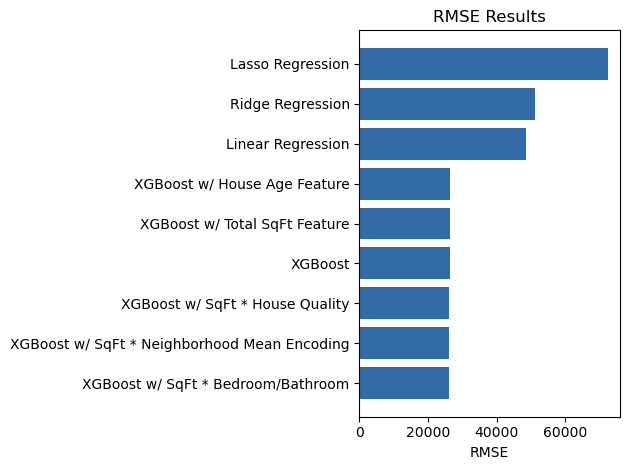

In [35]:
plt.barh(results_df['Model and Feature Engineering'], results_df['RMSE'], color='#326ba8')
plt.xlabel('RMSE')
plt.title('RMSE Results')
plt.tight_layout() 
plt.savefig('rmse_results_bar_chart.png')

### Best Model - Bedroom/Bathroom

In [125]:
xgb_model = XGBRegressor(
    n_estimators=1000,   # Number of trees
    learning_rate=0.1,  # How much to "listen" to each tree
    max_depth=3,         # How complex each tree can be
    random_state=42
)

def bedroom_divide_bathroom(df):
    df = df.copy()
    df['bedroom_divide_bathroom'] = df['BedroomAbvGr'] / (df['BsmtFullBath'] + df['BsmtHalfBath'] + df['FullBath'])
    #df['BsmtFullBath'] + df['BsmtHalfBath'] +
    return df

bedroom_divide_bathroom = FunctionTransformer(bedroom_divide_bathroom)

pipeline = Pipeline([
    ('inside_sq_ft', inside_sq_ft_transformer),
    ('sqft_times_quality', sqft_times_quality_transformer),
    ('bedroom_divide_bathroom', bedroom_divide_bathroom),
    ('pool_handler', pool_transformer),
    ('preprocessor', preprocessor),
    #('model', LinearRegression())
    ('model', xgb_model)
])

best_model = TransformedTargetRegressor(
    regressor=pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)


kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_cross_val = cross_val_score(estimator=best_model, X=X, y=y, cv=kf, scoring='neg_root_mean_squared_error')
mape_cross_val = cross_val_score(estimator=best_model, X=X, y=y, cv=kf, scoring='neg_mean_absolute_percentage_error')
print('Cross Val RMSE: ', np.mean(rmse_cross_val) * -1)
print('Cross Val MAPE: ', np.mean(mape_cross_val) * -1)

Cross Val RMSE:  23291.36640625
Cross Val MAPE:  0.08465382605791091


### Discussion

#### #1. The house price predictions made by the best model is off by $23,259 or 8.46% on average.

See code block above with the header, "Best Model - Bedroom/Bathroom".

The average sale price of a house in this dataset was $180,141.

#### #2. XGBoost helped to reduce RMSE the most. More than feature engineering.

Changing the model from Linear Regressor to XGBoost Regressor reduced the RMSE from 48,607 to 26,336, a reduction of 45.81%. On the other hand, the best feature created during feature engineering only decreased the RMSE by 1%.

#### #3. Using sklearn Pipeline and TransformedTargetRegressor allowed this analysis to be much more readable by containerizing what would have been large blocks of code dedicated to data cleaning such as imputation.

With sklearn Pipeline, I could ensure the data preprocessing done to my training set is the exact same preprocessing that was done on my test set. I only had to write the pipeline once and then I could pass any data I wanted through the pipeline.

add a discussion point about the most impactful features when used linear regressor

#### #4. Which features were most important to the linear model?

#### Added standard scaler because im looking at coefficients of linear model to see which features were thought to have most impact on sale price.

In [118]:
categorical_cols = ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
    'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 
        'KitchenQual',
        'Functional', 'FireplaceQu', 'GarageType',
        'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'Fence',
       'MiscFeature', 'SaleType',
       'SaleCondition']

numerical_cols = X.select_dtypes(include=['number']).columns.tolist()

#categorical columns that only need OHE
cat_ohe_columns = list(set(categorical_cols) - set(na_cat_columns))

#For categorical columns where you need to impute missing values and do OHE
cat_impute_ohe_pipeline = Pipeline([
    ('impute_na_categorical', na_imputer),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

#Consolidate previous and current ColumnTransformer into one, add OHE.
preprocessor = ColumnTransformer(transformers=[
    ('cat_impute_ohe', cat_impute_ohe_pipeline, na_cat_columns), #for cat columns that need imputation and OHE
    ('cat_ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_ohe_columns), #cat columns that ony need OHE
    ('standard_scaler', StandardScaler(), numerical_cols),
    ('impute_median', median_imputer, median_columns),
    ('impute_0', impute_0, ["MasVnrArea"])
], remainder='passthrough')

#Add linear regressor
pipeline = Pipeline([
    ('pool_handler', pool_transformer),
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model = TransformedTargetRegressor(
    regressor=pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

model.fit(X_train, y_train)
fitted_pipeline = model.regressor_
lr_step = fitted_pipeline.named_steps['regressor']
coefficients = lr_step.coef_
preprocessor_step = fitted_pipeline.named_steps['preprocessor']
feature_names = preprocessor_step.get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Weight': np.abs(coefficients)
}).sort_values(by='Weight', ascending=False)

indices_to_keep = []

for i in range(len(importance_df)):
    if 'ohe' not in importance_df.iloc[i]['Feature'] and 'remainder' not in importance_df.iloc[i]['Feature']:
        indices_to_keep.append(i)

numerical_importance_df = importance_df.iloc[indices_to_keep].copy()
numerical_importance_df = numerical_importance_df.sort_values(by = 'Weight', ascending = False)
numerical_importance_df.head()

,Feature,Weight
274,standard_scaler__GrLivArea,0.076518
291,standard_scaler__PoolArea,0.067487
272,standard_scaler__2ndFlrSF,0.056368
264,standard_scaler__YearBuilt,0.054600
262,standard_scaler__OverallQual,0.048880


The five most impactful numerical columns for predicting SalePrice were GrLivArea, PoolArea, 2ndFlrSF, YearBuilt, and OverallQual according to the Linear Regressor model.

### Kaggle Submission

In [128]:
best_model.fit(X, y)
test = pd.read_csv("test.csv")
predictions = best_model.predict(test)

In [129]:
submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': predictions
})
submission

,Id,SalePrice
0,1461,128442.773438
1,1462,161166.437500
2,1463,190997.312500
3,1464,197562.671875
4,1465,184248.890625
...,...,...
1454,2915,77647.671875
1455,2916,75872.453125
1456,2917,149076.687500
1457,2918,107595.609375


In [130]:
submission.to_csv('submission.csv', index=False)

perhaps look at why if change random_state for train test split there is a huge difference in error. that means some data points contribute a lot of error

erased most of the explanations of the effects of the feature engineerings were. ex: neighborhood feature engineering didnt change rmse. so i should add those back at the bottom of each feature